In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
train_path = "/kaggle/input/datasets/harshbhullar/regression-train-test/train.csv"
test_path = "/kaggle/input/datasets/harshbhullar/regression-train-test/test.csv"

In [4]:
df = pd.read_csv(train_path)
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
df.drop(['id', 'gender'], axis = 1, inplace = True)

In [6]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

**FEATURES EDA**

In [28]:
df['ExpectedCharges'] = df['tenure'] * df['MonthlyCharges']
df['ChargeDifference'] = df['TotalCharges'] - df['ExpectedCharges']

In [ ]:
columns = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for cols in columns:
    print(f"---Churn Rate for {cols}---")
    churn_analysis = df.groupby(cols)['Churn'].agg(['mean', 'count'])
    print(churn_analysis)
    print("\n") 

In [30]:
df['Household_Score'] = (df['Partner'] == 'Yes').astype(int) + (df['Dependents'] == 'Yes').astype(int)

print(df.groupby('Household_Score')['Churn'].mean())

Household_Score
0    0.332848
1    0.208176
2    0.065791
Name: Churn, dtype: float64


In [31]:
df['high_risk'] = (
    (df['SeniorCitizen'] == 1) &
    (df['InternetService'] == 'Fiber optic') &
    (df['TechSupport'] == 'No') &
    (df['Contract'] == 'Month-to-month') & 
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)
df['high_risk'].value_counts()
df.groupby('high_risk')['Churn'].mean() #concentrated group of churners. still 30% did not churn, why?

high_risk
0    0.194300
1    0.695678
Name: Churn, dtype: float64

In [32]:
streaming_cols = ['StreamingTV', 'StreamingMovies']

df['no_streaming_services'] = df[streaming_cols].isin(['No']).sum(axis=1)

df.groupby('no_streaming_services')['Churn'].mean() #since the middle ground has the peak, leaving it at ordinal only.

no_streaming_services
0    0.163094
1    0.328078
2    0.289357
Name: Churn, dtype: float64

In [33]:
targets = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

df['no_services'] = df[targets].isin(['No']).sum(axis=1)

df['is_vulnerable'] = (df['no_services'] == 4).astype(int)

df.groupby('is_vulnerable')['Churn'].mean()

df.groupby('no_services')['Churn'].mean() #the logic is solid since the churn rates increase with the number of counts for each 'No' of additional service

no_services
0    0.015696
1    0.062852
2    0.203209
3    0.394114
4    0.526530
Name: Churn, dtype: float64

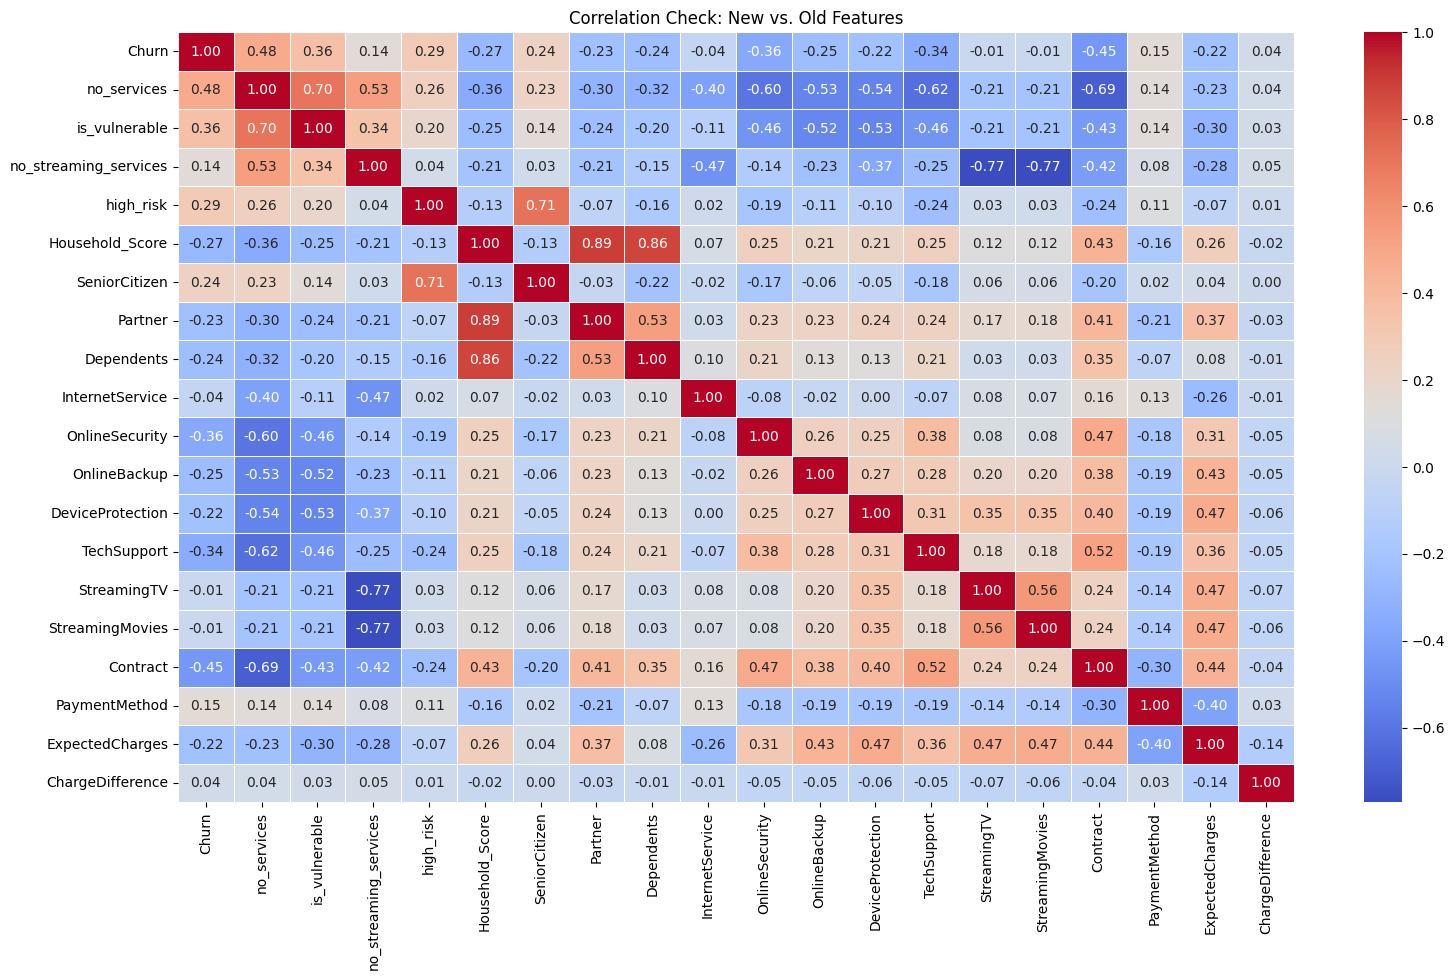

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

check_cols = [
    'Churn', 'no_services', 'is_vulnerable', 'no_streaming_services', 'high_risk', 'Household_Score', 'SeniorCitizen', 'Partner', 'Dependents', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'ExpectedCharges', 'ChargeDifference'
]

corr_matrix = df[check_cols].apply(lambda x: x.astype('category').cat.codes if x.dtype == 'object' else x).corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Check: New vs. Old Features")
plt.show()

Dropping Redundant Columns that have high collinearity with new features.

In [34]:
cols_to_drop = ['Partner', 'Dependents', 'StreamingTV', 'StreamingMovies', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

df.drop(cols_to_drop, axis=1, inplace=True)
df.head()

,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ExpectedCharges,ChargeDifference,Household_Score,high_risk,no_streaming_services,no_services,is_vulnerable
0,0,29,Yes,No,DSL,One year,Yes,Mailed check,60.10,1653.85,0,1742.90,-89.05,2,0,2,1,0
1,0,58,Yes,No,DSL,Two year,No,Credit card (automatic),69.50,3778.20,0,4031.00,-252.80,2,0,1,1,0
2,0,58,Yes,Yes,Fiber optic,Month-to-month,Yes,Electronic check,100.40,5841.35,0,5823.20,18.15,1,0,0,3,0
3,0,1,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,69.70,70.70,1,69.70,1.00,0,0,2,4,1
4,0,1,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,70.45,70.45,1,70.45,0.00,0,0,2,4,1


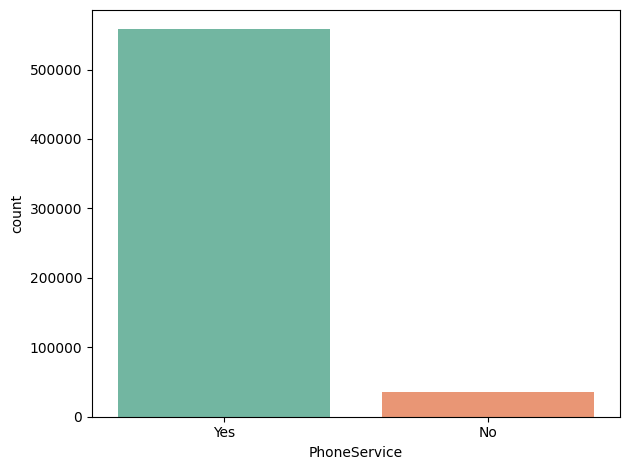

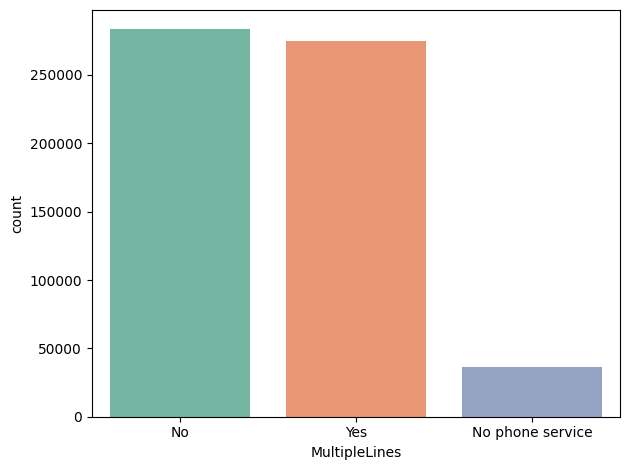

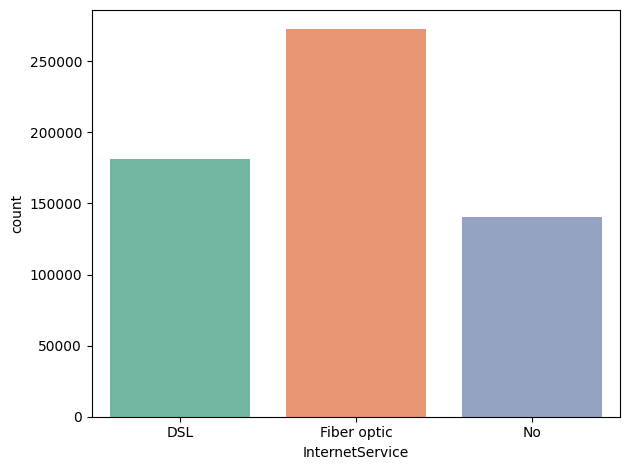

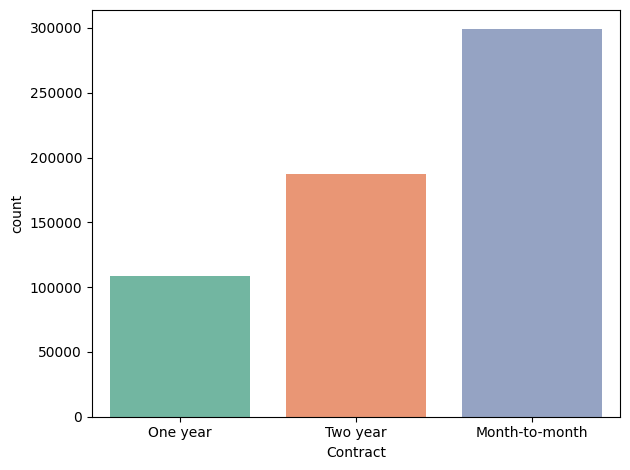

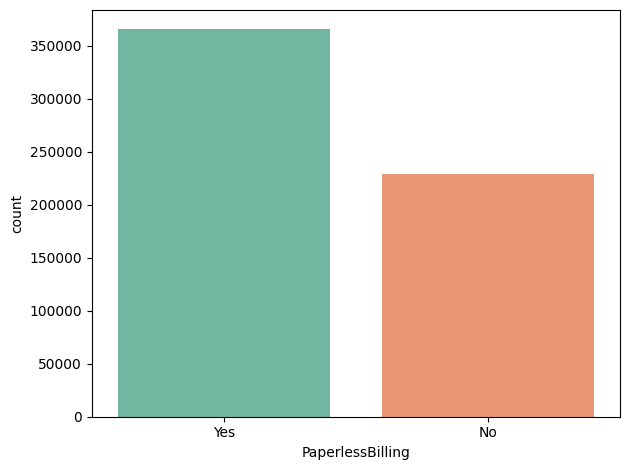

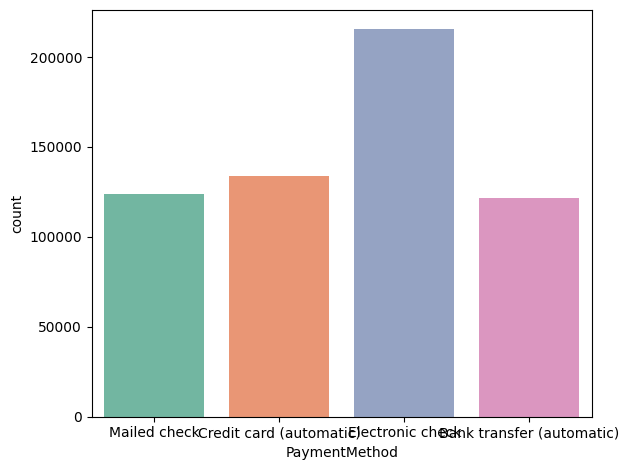

In [7]:
cat_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
for i in cat_cols:
    sns.countplot(data=df, x = i, hue = i, palette = 'Set2')
    plt.tight_layout()
    plt.show()

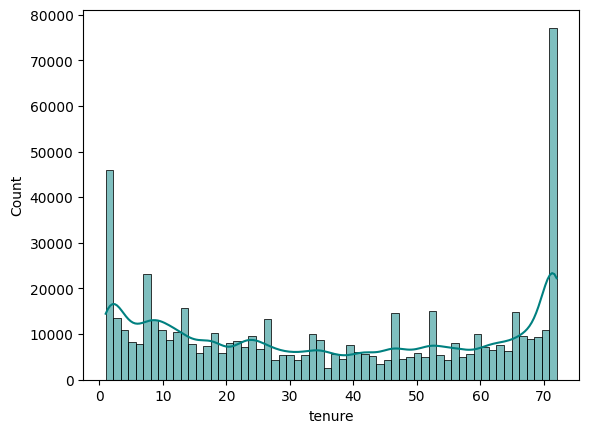

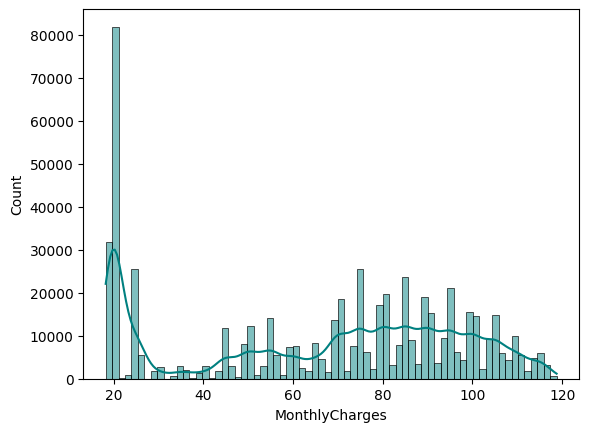

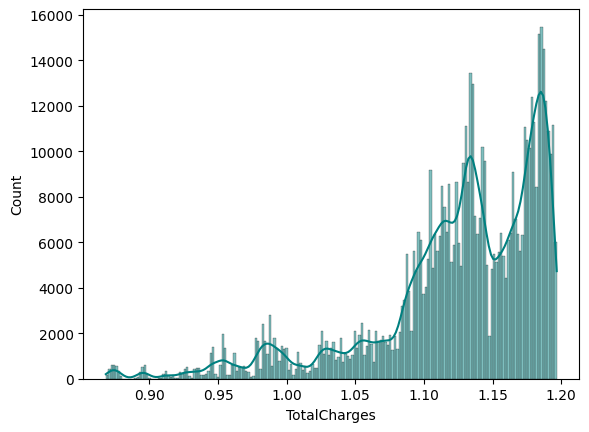

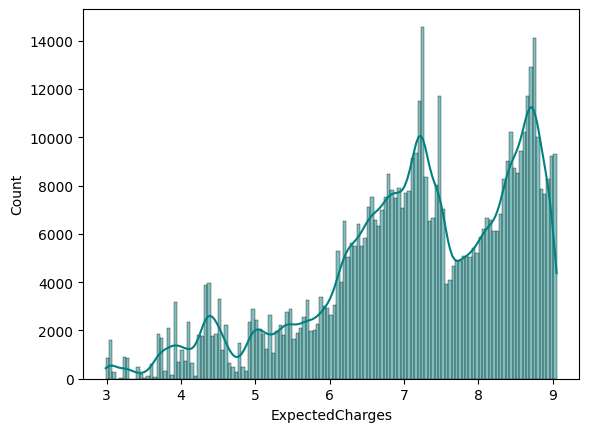

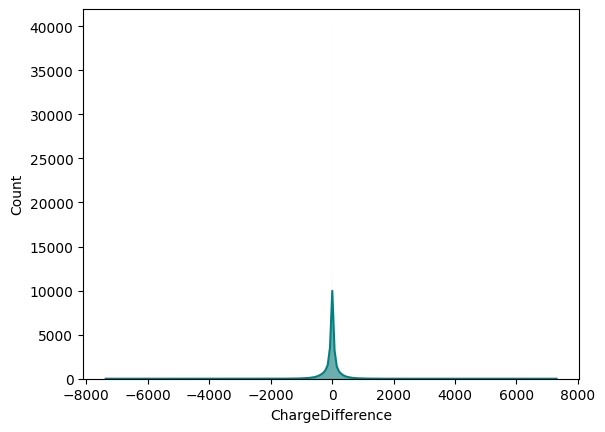

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ExpectedCharges', 'ChargeDifference']
for i in num_cols:
  sns.histplot(data = df, x = i, kde = True, color = 'teal')
  plt.show()

In [16]:
df

,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ExpectedCharges,ChargeDifference,Household_Score,high_risk,no_streaming_services,no_services,is_vulnerable
0,0,29,Yes,No,DSL,One year,Yes,Mailed check,60.10,1653.85,0,1742.90,-89.05,2,0,2,1,0
1,0,58,Yes,No,DSL,Two year,No,Credit card (automatic),69.50,3778.20,0,4031.00,-252.80,2,0,1,1,0
2,0,58,Yes,Yes,Fiber optic,Month-to-month,Yes,Electronic check,100.40,5841.35,0,5823.20,18.15,1,0,0,3,0
3,0,1,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,69.70,70.70,1,69.70,1.00,0,0,2,4,1
4,0,1,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,70.45,70.45,1,70.45,0.00,0,0,2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,Yes,Yes,Fiber optic,Two year,No,Bank transfer (automatic),97.55,5460.70,0,5560.35,-99.65,0,0,0,3,0
594190,0,72,Yes,Yes,DSL,Two year,No,Bank transfer (automatic),91.95,6782.15,0,6620.40,161.75,0,0,0,0,0
594191,0,72,Yes,Yes,No,Two year,No,Credit card (automatic),24.40,1871.90,0,1756.80,115.10,1,0,0,0,0
594192,0,32,Yes,Yes,Fiber optic,Month-to-month,Yes,Electronic check,86.00,2847.20,0,2752.00,95.20,0,0,1,4,1


**PREPROCESSING**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categoric_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
passthrough_cols =  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ExpectedCharges', 'ChargeDifference', 'no_services', 'is_vulnerable', 'no_streaming_services', 'high_risk', 'Household_Score']

# Features and Target Split
X = df[categoric_cols + passthrough_cols]
y = df['Churn']

#Train Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)
# X_train.shape, X_val.shape, y_train.shape, y_val.shape


preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), categoric_cols),
        ('num_passthrough', 'passthrough', passthrough_cols)
    ])
preprocessor

ColumnTransformer(transformers=[('ohe',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['PhoneService', 'MultipleLines',
                                  'InternetService', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num_passthrough', 'passthrough',
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges', 'ExpectedCharges',
                                  'ChargeDifference', 'no_services',
                                  'is_vulnerable', 'no_streaming_services',
                                  'high_risk', 'Household_Score'])])

**RANDOMIZED_SEARCH_CV ON DECISION TREE:** to find the best parameters

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

dtc_random_params = {
    'classifier__max_depth': randint(2,20),
    'classifier__min_samples_split': randint(2,20),
    'classifier__min_samples_leaf': randint(2,20),
    'classifier__criterion': ['gini', 'entropy', 'log_loss']
}

pipeline_dt = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

random_search_dt = RandomizedSearchCV(
    pipeline_dt,
    dtc_random_params,
    cv=5,
    verbose=3,
    n_jobs=1,
    scoring='roc_auc',
    return_train_score=True
)

random_search_dt.fit(X_train, y_train)

In [109]:
print(random_search_dt.best_params_)
print(random_search_dt.best_score_)

results_dt = random_search_dt.cv_results_

y_pred = random_search_dt.predict(X_val)
y_prob = random_search_dt.predict_proba(X_val)[:, 1]


from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
print("ROC-AUC Score:",roc_auc_score(y_val, y_prob)) 
print("------------------------------------------------------")
print("Classfication Report: \n", classification_report(y_val, y_pred))
print("------------------------------------------------------")
print("Confusion Matrix:\n",confusion_matrix(y_val, y_pred))

{'classifier__criterion': 'log_loss', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 19, 'classifier__min_samples_split': 14}
0.9085472075977826
ROC-AUC Score: 0.9096479123369318
------------------------------------------------------
Classfication Report: 
               precision    recall  f1-score   support

           0       0.89      0.93      0.91     91935
           1       0.71      0.61      0.66     26904

    accuracy                           0.86    118839
   macro avg       0.80      0.77      0.78    118839
weighted avg       0.85      0.86      0.85    118839

------------------------------------------------------
Confusion Matrix:
 [[85348  6587]
 [10483 16421]]


In [108]:
result = pd.DataFrame(results_dt)
result[['param_classifier__criterion', 'param_classifier__max_depth', 'param_classifier__min_samples_leaf', 
        'param_classifier__min_samples_split', 'mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False)

,param_classifier__criterion,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__min_samples_split,mean_train_score,std_train_score,mean_test_score,std_test_score
3,log_loss,8,19,14,0.910831,0.000233,0.908547,0.000730
2,entropy,13,16,17,0.923982,0.000348,0.900337,0.001070
7,log_loss,5,18,5,0.899947,0.000229,0.899633,0.000938
5,entropy,5,6,9,0.899947,0.000229,0.899633,0.000938
4,entropy,5,15,12,0.899947,0.000229,0.899633,0.000938
1,gini,5,12,19,0.899710,0.000341,0.899482,0.001014
8,entropy,4,19,19,0.889889,0.000210,0.889875,0.000938
6,log_loss,16,12,9,0.934961,0.000303,0.885881,0.001374
9,log_loss,2,14,2,0.847640,0.000130,0.847641,0.000520
0,gini,2,15,10,0.845221,0.000150,0.845223,0.000600


**FINAL DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix


pipeline_dt = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
    ])

dtc_params = {
    'classifier__max_depth': [8],
    'classifier__min_samples_split': [8],
    'classifier__criterion': ['gini']}

grid_search_final = GridSearchCV(
    pipeline_dt,
    dtc_params,
    cv=5,
    scoring='roc_auc',
    return_train_score = True
)

grid_search_final.fit(X_train, y_train)

results_dt = grid_search_final.cv_results_

y_pred = grid_search_final.predict(X_val)
y_prob = grid_search_final.predict_proba(X_val)[:, 1]


from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
print("ROC-AUC Score:",roc_auc_score(y_val, y_prob)) 
print("------------------------------------------------------")
print("Classfication Report: \n", classification_report(y_val, y_pred))
print("------------------------------------------------------")
print("Confusion Matrix:\n",confusion_matrix(y_val, y_pred))

In [ ]:
cv_results = pd.DataFrame(results_dt)
cv_results

**RANDOMIZED_SEARCH_CV ON RANDOM FOREST:** to find the best parameters range initially and then close in on the best parameters

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from scipy.stats import randint

# INITIALLY THE RANGE IS WIDE TO FIND THE NEAREST RANGE OF THE BEST PARAMETERS 
rfc_params_random_v1 = {
    'classifier__n_estimators': randint(10,500),
    'classifier__max_depth': randint(3,25),
    'classifier__min_samples_split': randint(2,20),
    'classifier__max_features': ['sqrt', 'log2']
}
# Best Params: {'classifier__max_depth': 16, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 17, 'classifier__n_estimators': 318}; Best Score: 0.913302


# THE SECOND VERSION CLOSES THE RANGE TO THE NEAREST VALUES OF THE PARAMETERS
rfc_params_random_v2 = {
    'classifier__n_estimators': randint(300,400),
    'classifier__max_depth': randint(14,18),
    'classifier__min_samples_split': randint(12,20),
    'classifier__max_features': ['sqrt', 'log2']
}
# Best Params: {'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 17, 'classifier__n_estimators': 392}; Best Score: 0.913331


# THE FINAL VERSION USES A GRID SEARCH ON THE BEST PARAMETERS FOUND THROUGH THE 2 ITERATIONS 
rfc_params_grid = {
    'classifier__n_estimators': [350], 
    'classifier__max_depth': [16], 
    'classifier__min_samples_split': [17],
    'classifier__min_samples_leaf': [10],
    'classifier__max_features': ['log2']
}
# Best Params: {'classifier__max_depth': 16, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 17, 'classifier__n_estimators': 350}; Best Score: 0.9134958177944954

In [ ]:
# RANDOM_SEARCH_CV PIPELINE

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


random_search_rf = RandomizedSearchCV(
    pipeline_rf,
    rfc_params_random_v2,
    cv=3,
    scoring='roc_auc',
    return_train_score = True,
    n_jobs=1,
    verbose=3,
    n_iter=40
)

random_search_rf.fit(X_train, y_train)

results_rf = random_search_rf.cv_results_

y_pred = random_search_rf.predict(X_val)
y_prob = random_search_rf.predict_proba(X_val)[:, 1]

print("ROC-AUC Score:",roc_auc_score(y_val, y_prob))
print("------------------------------------------------------")
print("Best Params: \n", random_search_rf.best_params_)
print("------------------------------------------------------")
print("Best Score:\n", random_search_rf.best_score_)
print("------------------------------------------------------")
print("Classfication Report: \n", classification_report(y_val, y_pred))
print("------------------------------------------------------")
print("Confusion Matrix:\n",confusion_matrix(y_val, y_pred))

In [ ]:
rf_results = pd.DataFrame(results_rf)
rf_results[['param_classifier__max_depth', 'param_classifier__max_features', 'param_classifier__min_samples_split', 'param_classifier__n_estimators',
            'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']].sort_values('rank_test_score', ascending=True)

**FINAL RANDOM FOREST**

In [ ]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


random_search_rf = GridSearchCV(
    pipeline_rf,
    rfc_params_grid,
    cv=5,
    scoring='roc_auc',
    return_train_score = True,
    n_jobs=1,
    verbose=3
)

random_search_rf.fit(X_train, y_train)

results_rf = random_search_rf.cv_results_

y_pred = random_search_rf.predict(X_val)
y_prob = random_search_rf.predict_proba(X_val)[:, 1]

print("ROC-AUC Score:",roc_auc_score(y_val, y_prob))
print("------------------------------------------------------")
print("Best Params: \n", random_search_rf.best_params_)
print("------------------------------------------------------")
print("Best Score:\n", random_search_rf.best_score_)
print("------------------------------------------------------")
print("Classfication Report: \n", classification_report(y_val, y_pred))
print("------------------------------------------------------")
print("Confusion Matrix:\n",confusion_matrix(y_val, y_pred))

# submission score: 91.06

**XGBOOST WITH OPTUNA:** finding the best parameters using a gradient based approach to handle the compute time taken by the system

In [19]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42
    }
    
    X_train_transformed = preprocessor.fit_transform(X_train).astype('float32')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_transformed, y_train, test_size=0.2, stratify=y_train
    )
    
    # Initialize and fit
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)
    
# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-03-25 18:31:11,669] A new study created in memory with name: no-name-a1d97f83-ce15-4065-8004-9df639cce4a9


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:31:14] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[I 2026-03-25 18:31:15,002] Trial 0 finished with value: 0.9122071720268744 and parameters: {'n_estimators': 350, 'max_depth': 6, 'learning_rate': 0.011689502279077413, 'gamma': 0.8857260703061689, 'subsample': 0.7119090214448786, 'colsample_bytree': 0.9158173815916298}. Best is trial 0 with value: 0.9122071720268744.
[I 2026-03-25 18:31:17,399] Trial 1 finished with value: 0.9139649316555334 and parameters: {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.034643945397453024, 'gamma': 0.0006825704089887117, 'subsample': 0.5536186374977039, 'colsample_bytree': 0.5493001907577744}. Best is trial 1 with value: 0.9139649316555334.
[I 2026-03-25 18:31:21,800] Trial 2 finished with value: 0.9161921571389648 and parameters: {'n_estimators': 750, 'max_depth': 6, 'learning_rate': 0.014204416435799639, 'gamma': 0.7060742042607998, 'subsample': 0.57361721313747, 'colsample_bytree': 0.5233394128404063}. Best is trial 2 with value: 0.9161921571389648.
[I 2026-03-25 18:31:24,288] Trial 3 fin

In [20]:
print(f"Best ROC-AUC Score: {study.best_value:.4f}")

print("Best Parameters found by Optuna:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_trial = study.best_trial
print(f"Best trial number: {best_trial.number}")

Best ROC-AUC Score: 0.9174
Best Parameters found by Optuna:
  n_estimators: 750
  max_depth: 4
  learning_rate: 0.12272811938411608
  gamma: 9.241857506443384e-08
  subsample: 0.7796263170372533
  colsample_bytree: 0.7082564807284787
Best trial number: 37


**FINAL XGBOOST**

In [21]:
final_params = {
    'n_estimators': 750,
    'max_depth': 4,
    'learning_rate': 0.1227,
    'gamma': 9.24e-08,
    'subsample': 0.7796,
    'colsample_bytree': 0.7082,
    'tree_method': 'hist',
    'device': 'cuda', # For Kaggle GPU
    'random_state': 42
}

final_model = xgb.XGBClassifier(**final_params)

X_train_transformed = preprocessor.fit_transform(X_train).astype('float32')
final_model.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7082, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=9.24e-08, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1227, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=750, n_jobs=None,
              num_parallel_tree=None, ...)

## **submission**

In [29]:
# LOADING THE TEST DATA
test_df = pd.read_csv(test_path)
original_test_ids = test_df['id']  # Save IDs for the final file

# APPLYING THE EXACT SAME FEATURE ENGINEERING TO TEST DATA 
test_df['ExpectedCharges'] = test_df['tenure'] * test_df['MonthlyCharges']
test_df['ChargeDifference'] = test_df['TotalCharges'] - test_df['ExpectedCharges']

test_df['Household_Score'] = (test_df['Partner'] == 'Yes').astype(int) + (test_df['Dependents'] == 'Yes').astype(int)

test_df['high_risk'] = (
    (test_df['SeniorCitizen'] == 1) &
    (test_df['InternetService'] == 'Fiber optic') &
    (test_df['TechSupport'] == 'No') &
    (test_df['Contract'] == 'Month-to-month') & 
    (test_df['PaymentMethod'] == 'Electronic check')
).astype(int)

streaming_cols = ['StreamingTV', 'StreamingMovies']
test_df['no_streaming_services'] = test_df[streaming_cols].isin(['No']).sum(axis=1)

targets = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
test_df['no_services'] = test_df[targets].isin(['No']).sum(axis=1)
test_df['is_vulnerable'] = (test_df['no_services'] == 4).astype(int)

# PREPROCESSOR PIPELINE
X_test_final = test_df[categoric_cols + passthrough_cols]
X_test_processed = preprocessor.transform(X_test_final).astype('float32')

# GENERATING PROBABILITES 
test_probs = final_model.predict_proba(X_test_processed)[:, 1]

# SAVING SUBMISSION
submission = pd.DataFrame({
    'id': original_test_ids,
    'Churn': test_probs
})

submission.to_csv('submission.csv', index=False)
print("Success! submission.csv is ready for upload.")

Success! submission.csv is ready for upload.
